In [1]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap


In [2]:

# Set seaborn style
sns.set_style("white")

# Define pretty names for plotting
pretty_names = {
    'measured': 'Experimental IC₅₀ Measurement',
    'mhc_log_y': 'MHCflurry log₁₀ IC₅₀ Prediction',
    'BA_Rank': 'NetMHCpan Rank',
    'prediction_x': 'ESMCBA log₁₀ IC₅₀ Prediction',
    'plddt': 'AF2 pLDDT',
    'mpnn': 'ProteinMPNN Score',
    'rmsd': 'AF2 RMSD',
    'i_pae': 'AF2 Interface PAE',
    'i_ptm': 'AF2 iPTM Score',
    'PERMUTATION_TEST': 'Anchor-Preserved Mutagenesis Baseline',
    'RANDOM_SAMPLED': 'Global Sequence Sampling Control',
    'Athena_MSI': 'HLA Athena MSi (Sarkizova et al. 2019)',
    'mhc_pred_0': 'HLApollo (Thrift et al. 2024)'
}


In [3]:

# Load shared peptide datasets
rfd_peptides_all = pd.read_csv('../data/rdfiffusion_output_peptides.csv.gz', compression='gzip')
peptides_eval_set_ESMCBA = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/performances/predictions_of_models.csv')
umap_files = glob.glob('/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/A0201*epitope*_umap.csv')

# Load and concatenate HLA Athena data
hla_athena_files = [
    '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/rdfiffusion/predictions_20250501.211412.tsv',
    '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/rdfiffusion/predictions_20250501.213202.tsv',
    '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/rdfiffusion/predictions_20250501.214047.tsv'
]
hla_athena = pd.concat(
    [pd.read_csv(f, sep='\t')[['pep', 'MSi_A0201']] for f in hla_athena_files],
    ignore_index=True
)

# Load HLAPOLLO data
hla_pollo = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/rdfiffusion/RFDIFFUSION_HLAPOLLO.csv')

In [4]:

# Create empty list to collect merged DataFrames
all_predictions = []

# Process each UMAP file
for file in umap_files:
    filename = os.path.basename(file)
    hla = filename.split('_')[0]
    if 'epitope' not in filename or 'A0201' not in filename:
        continue

    # Load UMAP predictions
    escmba_predictions = pd.read_csv(file)
    
    # Load and process MHCflurry data
    mhcflurry = pd.read_csv(f'/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/{hla}FINAL_RS_RFD_MAC__mhc_flurry.csv')
    mhcflurry['mhc_log'] = mhcflurry['mhcflurry_affinity'].apply(np.log10)
    
    # Load NetMHCpan data
    try:
        netmhcspan = pd.read_csv(
            f'/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/FINAL_RS_RFD_MAC__{hla}_netmhc.xls',
            sep='\t',
            header=1
        )
    except:
        print(f"Warning: Failed to load NetMHCpan data for {hla}. Skipping this file.")
        continue

    # Subset RFD peptides for this HLA
    rfd_peptides = rfd_peptides_all[rfd_peptides_all['hla_allele'] == hla]
    if len(rfd_peptides) == 0:
        continue

    # Subset evaluation set
    peptides_eval = peptides_eval_set_ESMCBA[peptides_eval_set_ESMCBA['Model'] == f'{hla} HLA']

    # Merge data
    escmba_predictions = pd.merge(escmba_predictions, peptides_eval, on='sequence', how='left')
    escmba_predictions = pd.merge(escmba_predictions, rfd_peptides, left_on='sequence', right_on='epitope', how='left')
    escmba_predictions = pd.merge(escmba_predictions, mhcflurry[['peptide', 'mhc_log', 'mhcflurry_presentation_score']],
                                left_on='sequence', right_on='peptide', how='left')
    escmba_predictions = pd.merge(escmba_predictions, netmhcspan[['Peptide', 'BA_Rank']],
                                left_on='sequence', right_on='Peptide', how='left')
    escmba_predictions['HLA'] = hla

    # Add random sampled data
    random_sampled = pd.read_csv('../data/9mers_esm2.csv')
    escmba_predictions['RANDOM_SAMPLED'] = escmba_predictions['sequence'].isin(random_sampled['sequence'])
    escmba_predictions['PERMUTATION_TEST'] = (~escmba_predictions['RANDOM_SAMPLED']) & (escmba_predictions['plddt'].isna())

    # Merge with HLAPOLLO and Athena data
    escmba_predictions = pd.merge(escmba_predictions, hla_pollo[['peptide', 'mhc_pred_0']],
                                left_on='sequence', right_on='peptide', how='left').drop(columns=['peptide'])
    escmba_predictions = pd.merge(escmba_predictions, hla_athena,
                                left_on='sequence', right_on='pep', how='left').drop(columns=['pep']).rename(
                                columns={'MSi_A0201': 'Athena_MSI'})

    all_predictions.append(escmba_predictions)

# Combine all predictions
dt = pd.concat(all_predictions, ignore_index=True)
dt = dt.drop_duplicates()
dt.head()

,sequence,prediction_x,UMAP_1,UMAP_2,prediction_y,measured,Model,HLA,allele_x,allele_y,...,length_y,peptide_y,mhc_log_y,mhcflurry_presentation_score_y,Peptide_y,BA_Rank,RANDOM_SAMPLED,PERMUTATION_TEST,mhc_pred_0,Athena_MSI
0,RAKLLGAEEK,4.577079,7.251934,5.710631,3.951706,4.698979,A0201 HLA,A0201,A0201,HLAA0201,...,NaN,RAKLLGAEEK,4.443091,0.004254,RAKLLGAEEK,62.4692,False,True,-31.077397,0.000137
8,GRAKLLGAEEK,4.602308,7.546750,6.077731,3.989661,4.698979,A0201 HLA,A0201,A0201,HLAA0201,...,NaN,GRAKLLGAEEK,4.415553,0.006562,GRAKLLGAEEK,79.6991,False,True,-30.036451,0.000187
9,FGLAKLLGA,3.506930,2.841492,6.513256,3.785334,2.032256,A0201 HLA,A0201,A0201,HLAA0201,...,NaN,FGLAKLLGA,3.076028,0.207420,FGLAKLLGA,6.1584,False,True,-33.143314,0.090378
10,GLAKLLGAEEK,4.271616,5.082448,6.895719,3.868891,4.698979,A0201 HLA,A0201,A0201,HLAA0201,...,NaN,GLAKLLGAEEK,4.217983,0.010132,GLAKLLGAEEK,44.5145,False,True,-30.917457,0.005909
11,LAKLLGAEEK,4.831376,7.130169,5.602576,4.085848,4.698979,A0201 HLA,A0201,A0201,HLAA0201,...,NaN,LAKLLGAEEK,4.429933,0.003987,LAKLLGAEEK,59.4109,False,True,-33.439680,0.000209


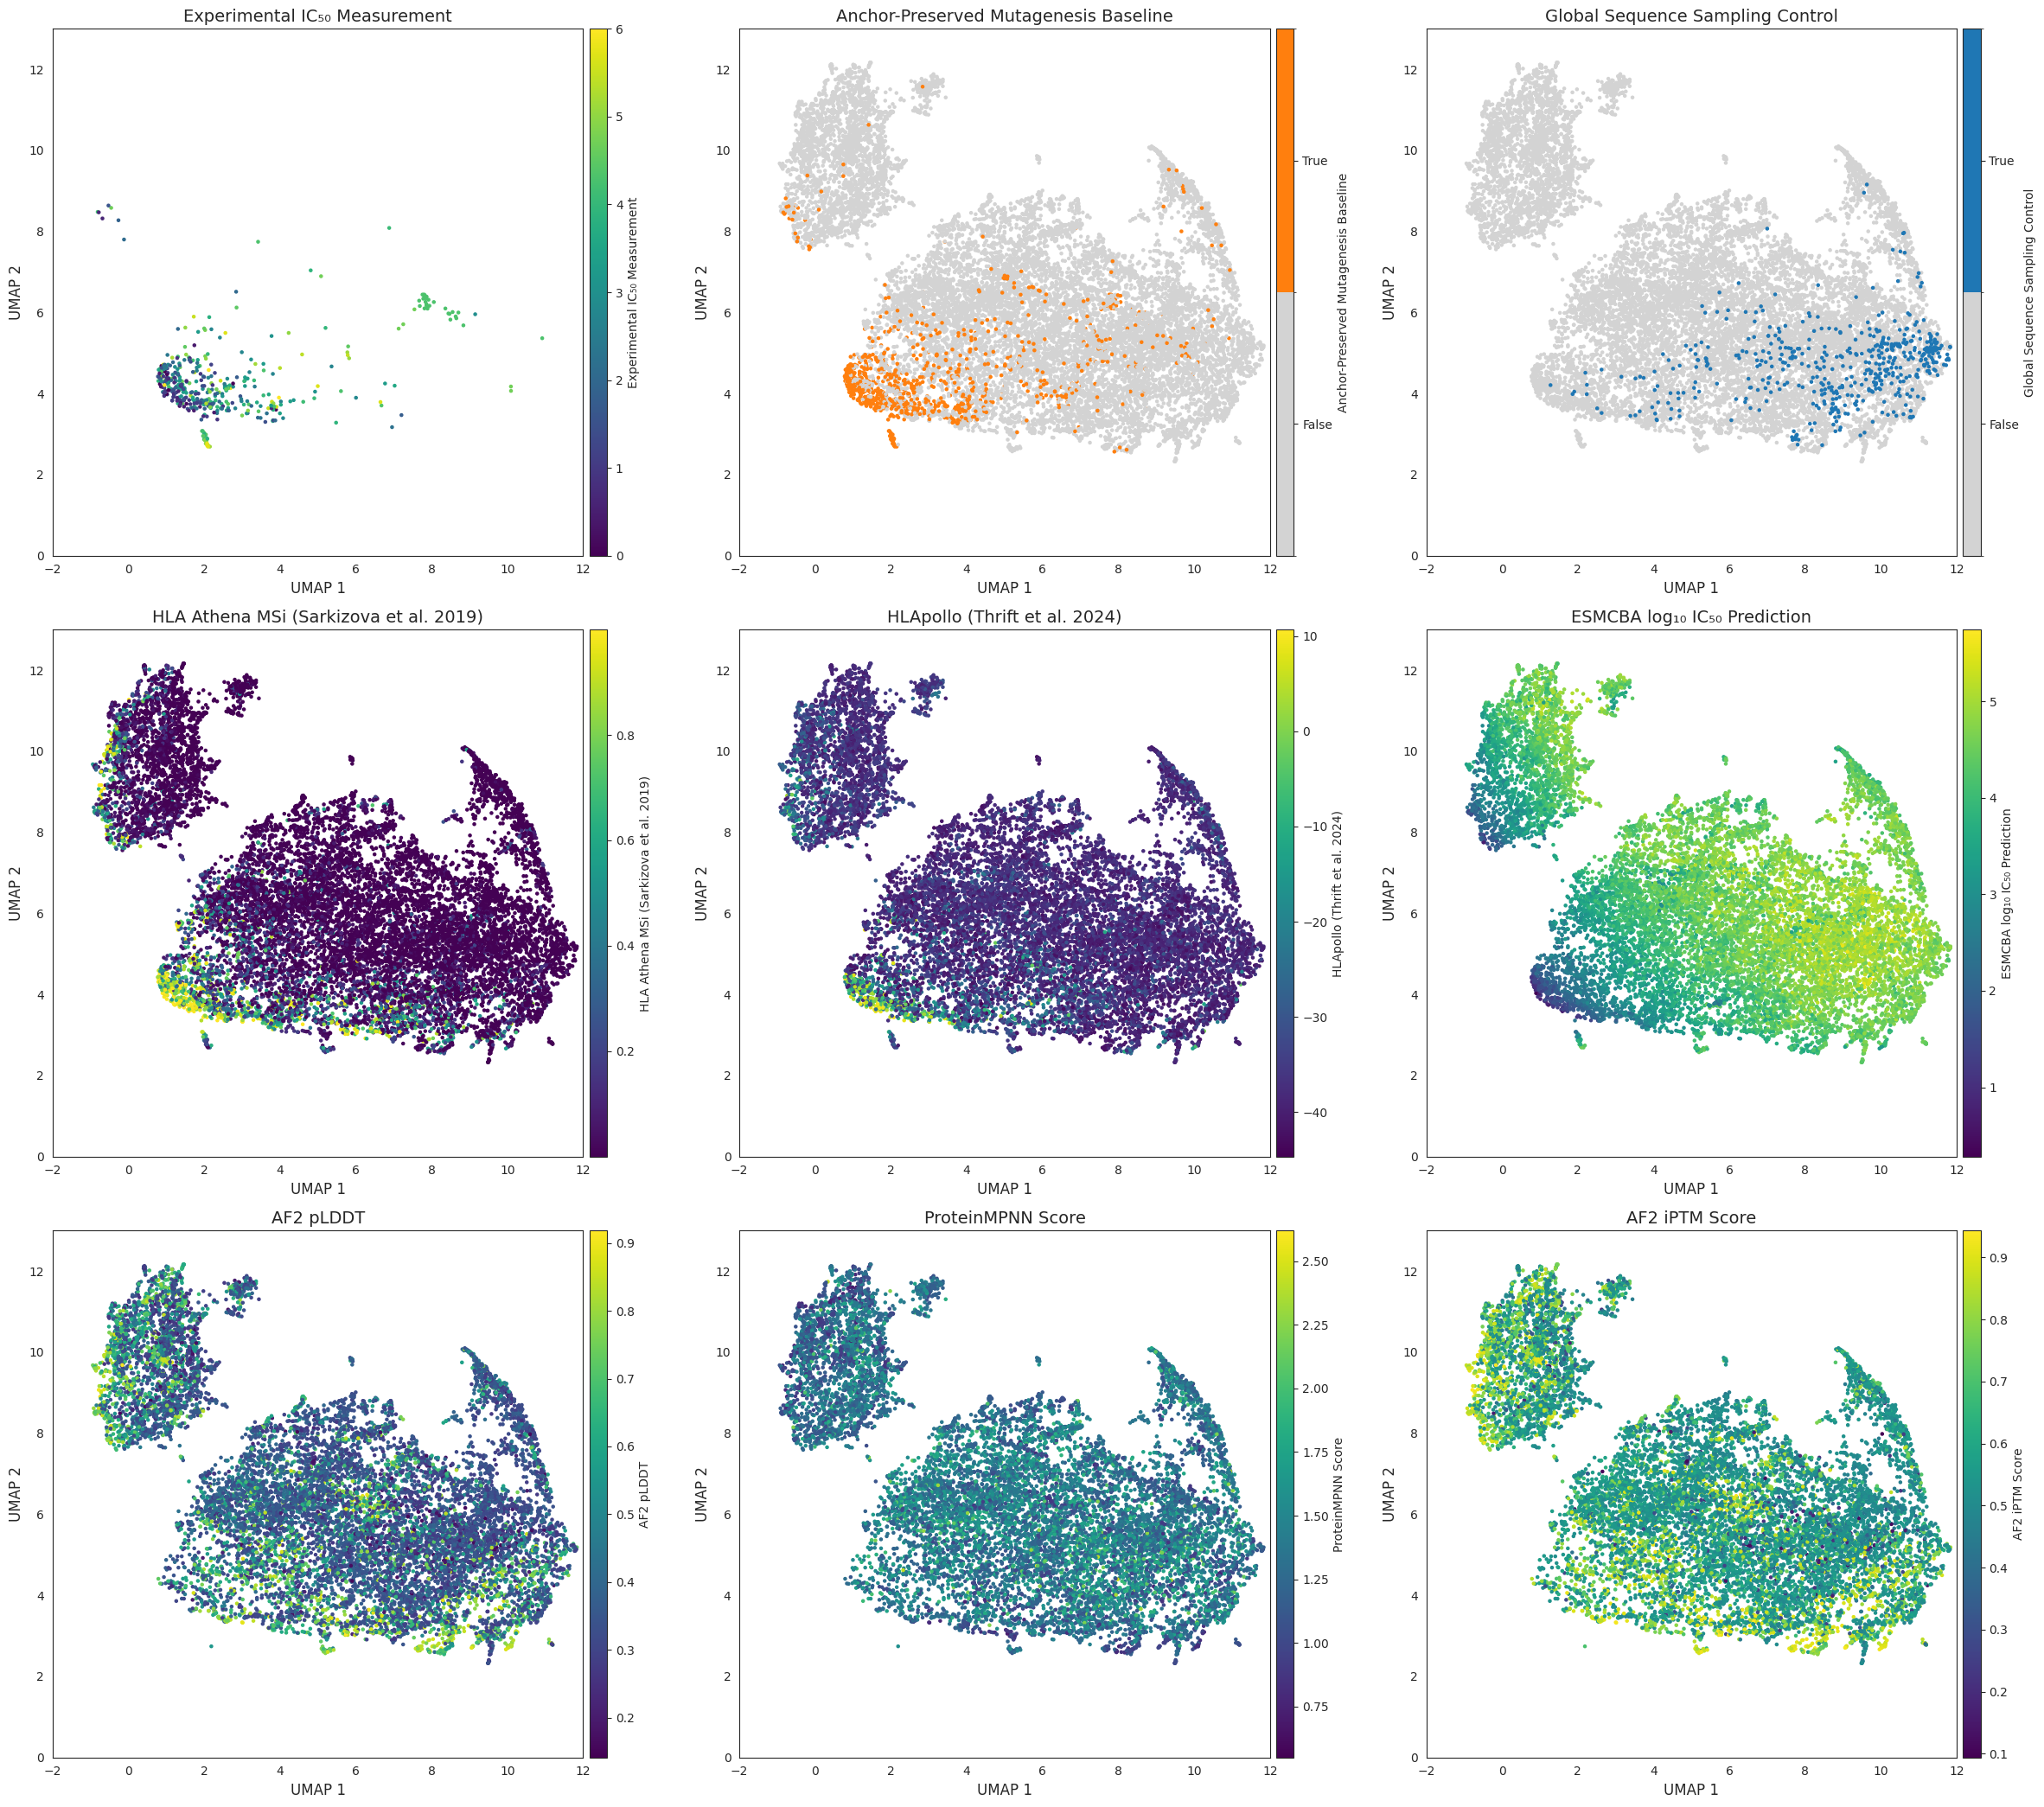

In [5]:

# Define columns for plotting
hue_columns = [
    'measured', 'PERMUTATION_TEST', 'RANDOM_SAMPLED', 'Athena_MSI',
    'mhc_pred_0', 'prediction_x', 'plddt', 'mpnn', 'i_ptm'
]

# Create subplots
n_cols = 3
n_rows = (len(hue_columns) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 7 * n_rows))
axes = axes.flatten()

# Define discrete colormaps
perm_cmap = ListedColormap(['lightgray', 'tab:orange'])
random_cmap = ListedColormap(['lightgray', 'tab:blue'])

# Plot each hue variable
for idx, hue_var in enumerate(hue_columns):
    ax = axes[idx]
    subset = dt[dt[hue_var].notna()]
    
    # Choose colormap and normalization
    if hue_var == 'PERMUTATION_TEST':
        cmap = perm_cmap
        norm = mcolors.BoundaryNorm([0, 0.5, 1], perm_cmap.N)
    elif hue_var == 'RANDOM_SAMPLED':
        cmap = random_cmap
        norm = mcolors.BoundaryNorm([0, 0.5, 1], random_cmap.N)
    else:
        cmap = 'viridis'
        norm = None

    # Create scatter plot
    points = ax.scatter(
        subset['UMAP_1'], subset['UMAP_2'],
        c=subset[hue_var], cmap=cmap, norm=norm, s=5, edgecolor=None
    )
    
    # Set plot titles and labels
    title_str = pretty_names.get(hue_var, hue_var)
    ax.set_title(title_str, fontsize=14)
    ax.set_xlabel('UMAP 1', fontsize=12)
    ax.set_ylabel('UMAP 2', fontsize=12)
    ax.set_xlim(-2, 12)
    ax.set_ylim(0, 13)

    # Add colorbar
    cbar = fig.colorbar(points, ax=ax, orientation='vertical', pad=0.01, aspect=30)
    cbar.set_label(title_str, fontsize=10)
    
    # Set discrete ticks for baseline variables
    if hue_var in ('PERMUTATION_TEST', 'RANDOM_SAMPLED'):
        cbar.set_ticks([0.25, 0.75])
        cbar.set_ticklabels(['False', 'True'])

plt.tight_layout()
plt.show()

In [6]:
main_combined = pd.read_csv('../data/main_df_updated_with_ApolloAthenaNuggetMix.csv')[['sequence', 'MixMHCpred_%Rank',	'mhc_nuggets_ic50'	,'HLApollo_pred']]
main_combined

/tmp/ipykernel_4092377/435987155.py:1: DtypeWarning: Columns (13,14,44,45,46,47,48,49,50,52,53,54,55,57,60,62,63,64) have mixed types. Specify dtype option on import or set low_memory=False.
  main_combined = pd.read_csv('../data/main_df_updated_with_ApolloAthenaNuggetMix.csv')[['sequence', 'MixMHCpred_%Rank',	'mhc_nuggets_ic50'	,'HLApollo_pred']]


,sequence,MixMHCpred_%Rank,mhc_nuggets_ic50,HLApollo_pred
0,SDLSLGPEA,7.792164,19936.59,-38.507525
1,SSLSLGPEA,7.647168,3718.61,-37.665597
2,SSLSLGPHA,9.047483,4354.81,-39.210855
3,SSLSLGFHA,9.417264,864.03,-37.809690
4,SDLSLGFEA,8.101418,14841.26,-37.442533
...,...,...,...,...
25667,FVLASLCLYVV,0.877758,202.51,-41.735909
25668,GMLPSNYVEAI,0.808441,1501.70,-33.143410
25669,FLAFTGVAGYI,3.527624,11.98,-36.668565
25670,FLCEILRSMSI,0.932169,6.49,-36.591447


In [7]:
dt_merged = dt.merge(main_combined, left_on='sequence', right_on='sequence', how='left')

In [8]:
dt = dt_merged

In [9]:
from sklearn.metrics import roc_curve, auc

# --- Predictors (True => invert so higher = better) ---
predictor_columns = {
    "MHCflurry": ("mhc_log_y", True),
    "NetMHCpan %Rank": ("BA_Rank", True),
    "ESMCBA log IC50": ("prediction_x", True),
    "HLAthena %Rank": ("Athena_MSI", False),          
    "Apollo inverse": ("HLApollo_pred", False),
    "MHC Nugget": ("mhc_nuggets_ic50", True),
    "MixMHCPred %Rank": ("MixMHCpred_%Rank", True),
}

# --- Fixed colors per model (consistent across all panels) ---
model_colors = {
    "MHCflurry": "C0",
    "NetMHCpan %Rank": "C1",
    "ESMCBA log IC50": "C2",
    "HLAthena %Rank": "C3",
    "Apollo inverse": "C4",
    "MHC Nugget": "C5",
    "MixMHCPred %Rank": "C6",
}

# --- Panels and labels ---
def subset_and_labels(df, key):
    if key == "Validated tested\nbinders vs non-binders":
        mask = (df["measured"] < 2) | (df["measured"] > 4)
        labels = (df.loc[mask, "measured"] < 2).astype(int)

    elif key == "Validated strong\nbinders vs ESM2 random":
        mask = (df["measured"] < 2) | (df["RANDOM_SAMPLED"])
        labels = (df.loc[mask, "measured"] < 2).astype(int)

    elif key == "Anchor-preserved\nvs ESM2 random":
        mask = df["PERMUTATION_TEST"] | df["RANDOM_SAMPLED"]
        labels = df.loc[mask, "PERMUTATION_TEST"].astype(int)

    elif key == "Diffusion designs\nvs ESM2 random":
        mask = (df["plddt"] > 0.8) | (df["RANDOM_SAMPLED"])
        labels = (df.loc[mask, "plddt"] > 0.8).astype(int)

    elif key == "Diffusion designs\nvs Binders":
        mask = (df["plddt"] > 0.8) | (df["measured"] < 2)
        labels = (df.loc[mask, "plddt"] > 0.8).astype(int)

    elif key == "Diffusion designs\nvs Anchor-preserved":
        mask = (df["plddt"] > 0.8) | (df["PERMUTATION_TEST"])
        labels = (df.loc[mask, "plddt"] > 0.8).astype(int)

    else:
        raise ValueError(key)

    return mask, labels

In [10]:
eval_panels = [
    "Validated tested\nbinders vs non-binders",
    "Validated strong\nbinders vs ESM2 random",
    "Anchor-preserved\nvs ESM2 random",
    "Diffusion designs\nvs ESM2 random",
    "Diffusion designs\nvs Binders",
    "Diffusion designs\nvs Anchor-preserved",
]

def safe_scores(y):
    y = pd.to_numeric(y, errors="coerce").astype(float)
    y[~np.isfinite(y)] = np.nan
    return y.values

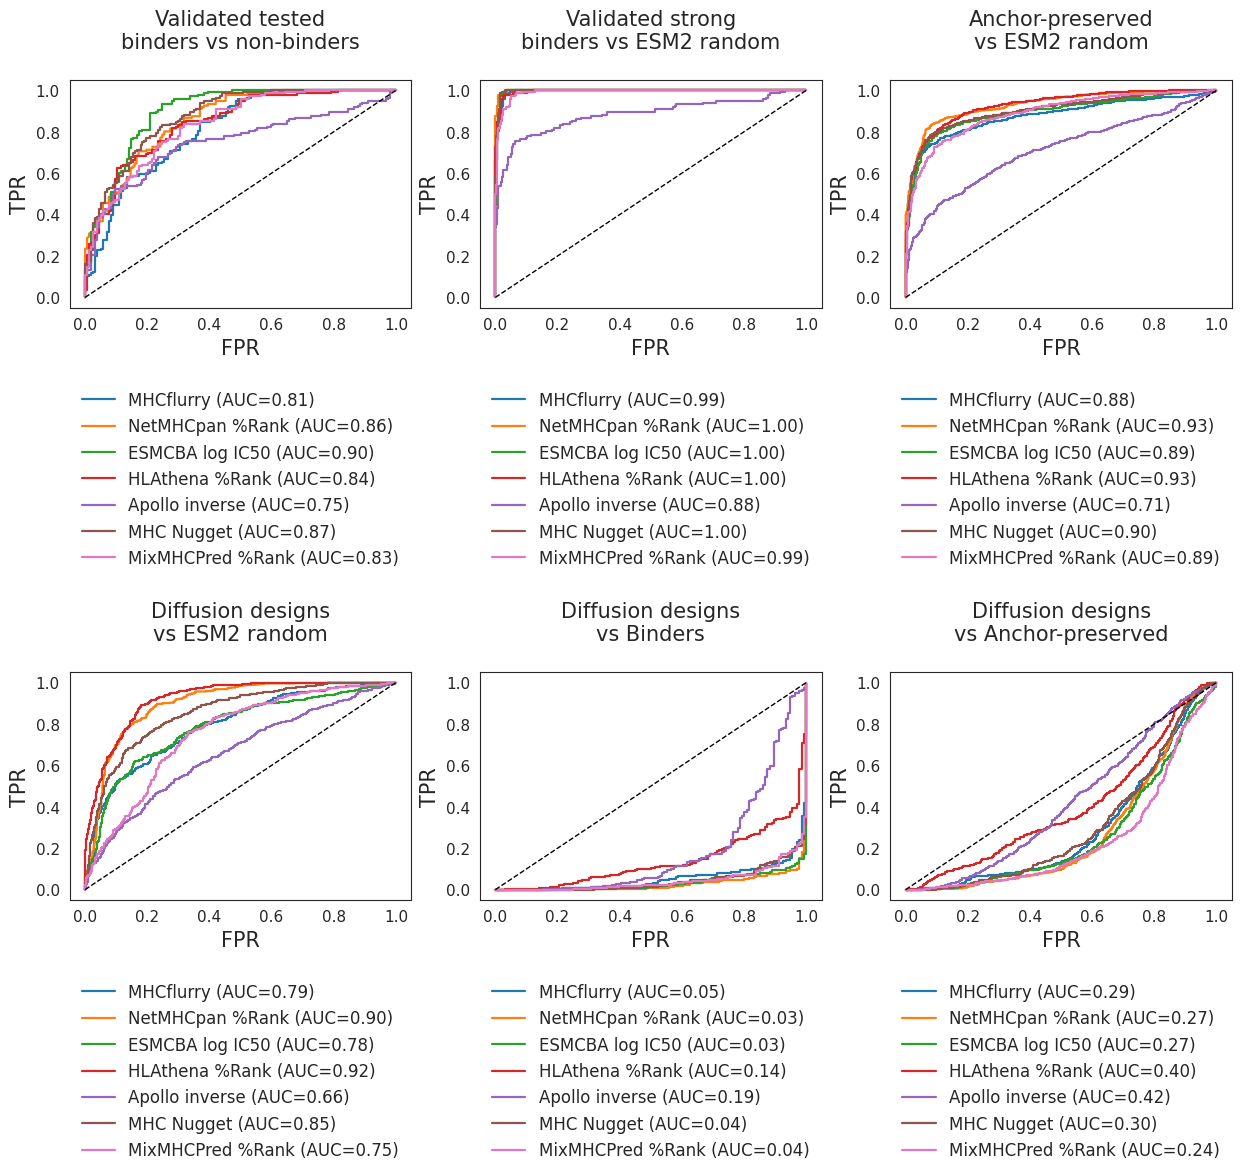

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=False, sharey=False)
axes = axes.ravel()

TITLE_FONTSIZE = 15
AXIS_FONTSIZE = 15
TICK_FONTSIZE = 11
LEGEND_FONTSIZE = 12  # slightly smaller for fit

model_order = list(predictor_columns.keys())

for ax, key in zip(axes, eval_panels):
    mask, labels = subset_and_labels(dt, key)
    sub = dt.loc[mask].copy()
    sub["label"] = labels.values

    legend_handles = []
    for model_name in model_order:
        col, invert = predictor_columns[model_name]
        color = model_colors[model_name]
        can_compute = col in sub.columns and sub["label"].nunique() > 1

        if can_compute:
            y_true = sub["label"].values
            y_score = safe_scores(sub[col])
            valid = ~np.isnan(y_score)
            y_true = y_true[valid]
            y_score = y_score[valid]
            if invert:
                y_score = -y_score
            fpr, tpr, _ = roc_curve(y_true, y_score)
            model_auc = auc(fpr, tpr)
            h, = ax.plot(fpr, tpr, lw=1.6, color=color,
                         label=f"{model_name} (AUC={model_auc:.2f})")
        else:
            h, = ax.plot([], [], lw=1.6, color=color,
                         label=f"{model_name} (AUC=NA)")
        legend_handles.append(h)

    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title(key + '\n', fontsize=TITLE_FONTSIZE)
    ax.set_xlabel("FPR", fontsize=AXIS_FONTSIZE)
    ax.set_ylabel("TPR", fontsize=AXIS_FONTSIZE)
    ax.tick_params(axis='both', which='major', labelsize=TICK_FONTSIZE)
    ax.grid(False)

    # Legend directly below each subplot
    ax.legend(
        handles=legend_handles,
        fontsize=LEGEND_FONTSIZE,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.30),  # more space
        frameon=False,
        ncol=1
    )

# Increase vertical spacing so legends don't overlap
plt.subplots_adjust(hspace=1.6, bottom=0.1, top=0.92)
plt.savefig("../figures/benchmark_roc_curves.pdf", dpi=300, bbox_inches='tight')
plt.show()


In [12]:
import math
from functools import lru_cache
from collections import Counter
from scipy.spatial.distance import jensenshannon

# ——— load IEDB & build train_dict as before ———
def load_iedb(alleles, n=1000):
    rows = []
    for h in alleles:
        path = f"/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLA{h}_final.csv"
        seqs = pd.read_csv(path, header=None, usecols=[0,8])
        seqs = seqs[seqs[8]=='Positive-High'].iloc[:,0]
        idx = np.random.choice(len(seqs), size=min(n, len(seqs)), replace=False)
        for s in seqs.iloc[idx]:
            rows.append((s, h))
    return pd.DataFrame(rows, columns=["sequence","HLA"])

iedb = load_iedb(dt.HLA.unique())

train_dict = {
    h: sub.groupby(sub.sequence.str.len())['sequence'].apply(list).to_dict()
    for h, sub in iedb.groupby('HLA')
}

# ——— build background frequencies & vectors for entropy/JSD ———
all_train = "".join(iedb.sequence)
bg_counts = Counter(all_train)
total_bg = sum(bg_counts.values())
bg_freq = {aa: cnt/total_bg for aa, cnt in bg_counts.items()}

# Specify amino-acid order
AAs   = list("ACDEFGHIKLMNPQRSTVWY")
# background probability vector in that order
bg_vec = np.array([bg_freq.get(aa, 1e-8) for aa in AAs])

# ——— similarity / entropy / distance functions ———

def max_identity(seq, ref_dict):
    L, best = len(seq), 0
    for l, refs in ref_dict.items():
        for r in refs:
            sc = sum(a==b for a,b in zip(seq, r)) / max(L, l)
            best = max(best, sc)
            if best == 1: return 1
    return best

def min_norm_identity(seq, ref_dict):
    L, best = len(seq), 0
    for l, refs in ref_dict.items():
        for r in refs:
            sc = sum(a==b for a,b in zip(seq, r)) / min(L, l) if min(L, l)>0 else 0
            best = max(best, sc)
            if best == 1: return 1
    return best

def shannon_entropy(seq, _=None):
    counts = Counter(seq)
    L = len(seq)
    return -sum((c/L) * math.log2(c/L) for c in counts.values())

def cross_entropy(seq, _=None, eps=1e-8):
    return -sum(math.log2(bg_freq.get(a, eps)) for a in seq) / len(seq)

def comp_vec(seq):
    cnt = Counter(seq)
    L   = len(seq)
    return np.array([cnt.get(aa,0)/L for aa in AAs])

def js_distance(seq, _=None):
    p = comp_vec(seq)
    # scipy’s jensenshannon returns the sqrt(JS divergence)
    return jensenshannon(p, bg_vec, base=2)

def euclid_dist(seq, _=None):
    p = comp_vec(seq)
    # Euclidean distance to the background AA-frequency vector
    return np.linalg.norm(p - bg_vec)

# ——— apply all metrics in one loop ———
sim_funcs = {
    'max_id':      max_identity,
    'min_id':      min_norm_identity,
    'H_comp':      shannon_entropy,
    'H_cross':     cross_entropy,
    'JS_dist':     js_distance,
    'Euclid_dist': euclid_dist,
}

for col, func in sim_funcs.items():
    dt[col] = [
        func(seq, train_dict.get(h, {}))
        for seq, h in zip(dt.sequence, dt.HLA)
    ]

dt.head()

,sequence,prediction_x,UMAP_1,UMAP_2,prediction_y,measured,Model,HLA,allele_x,allele_y,...,Athena_MSI,MixMHCpred_%Rank,mhc_nuggets_ic50,HLApollo_pred,max_id,min_id,H_comp,H_cross,JS_dist,Euclid_dist
0,RAKLLGAEEK,4.577079,7.251934,5.710631,3.951706,4.698979,A0201 HLA,A0201,A0201,HLAA0201,...,0.000137,52.392681,30215.69,-31.077397,0.300000,0.333333,2.521928,4.368856,0.687397,0.350704
1,GRAKLLGAEEK,4.602308,7.546750,6.077731,3.989661,4.698979,A0201 HLA,A0201,A0201,HLAA0201,...,0.000187,59.731588,32237.50,-30.036451,0.363636,0.444444,2.550341,4.375969,0.687990,0.347648
2,FGLAKLLGA,3.506930,2.841492,6.513256,3.785334,2.032256,A0201 HLA,A0201,A0201,HLAA0201,...,0.090378,4.132587,4895.60,-33.143314,0.555556,0.555556,2.197160,3.654091,0.641105,0.338067
3,GLAKLLGAEEK,4.271616,5.082448,6.895719,3.868891,4.698979,A0201 HLA,A0201,A0201,HLAA0201,...,0.005909,13.212064,20669.80,-30.917457,0.454545,0.555556,2.299896,4.073176,0.685117,0.349397
4,LAKLLGAEEK,4.831376,7.130169,5.602576,4.085848,4.698979,A0201 HLA,A0201,A0201,HLAA0201,...,0.000209,59.540074,25843.43,-33.439680,0.400000,0.444444,2.246439,4.035785,0.684687,0.357730


In [13]:
# 1) Normalize flags
for col in ["RANDOM_SAMPLED", "PERMUTATION_TEST"]:
    if col in dt.columns:
        dt[col] = dt[col].fillna(False).astype(bool)
    else:
        dt[col] = False

# 2) Build Method labels (rename as requested)
plddt_thr = 0.80
plddt_notna = dt["plddt"].notna()

conditions = [
    dt["RANDOM_SAMPLED"],
    (~dt["RANDOM_SAMPLED"]) & dt["PERMUTATION_TEST"],
    (~dt["RANDOM_SAMPLED"]) & (~dt["PERMUTATION_TEST"]) & plddt_notna & (dt["plddt"] >= plddt_thr),
    (~dt["RANDOM_SAMPLED"]) & (~dt["PERMUTATION_TEST"]) & plddt_notna & (dt["plddt"] < plddt_thr),
]
choices = [
    "Global sequence sample",   # was Random-sampled
    "Anchor-preserved",         # was Permutation-test
    f"PLDDT ≥ {plddt_thr:.2f}",
    f"PLDDT < {plddt_thr:.2f}",
]
dt["Method"] = np.select(conditions, choices, default="Unlabeled")

/tmp/ipykernel_4092377/335087274.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4092377/335087274.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4092377/335087274.py:185: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


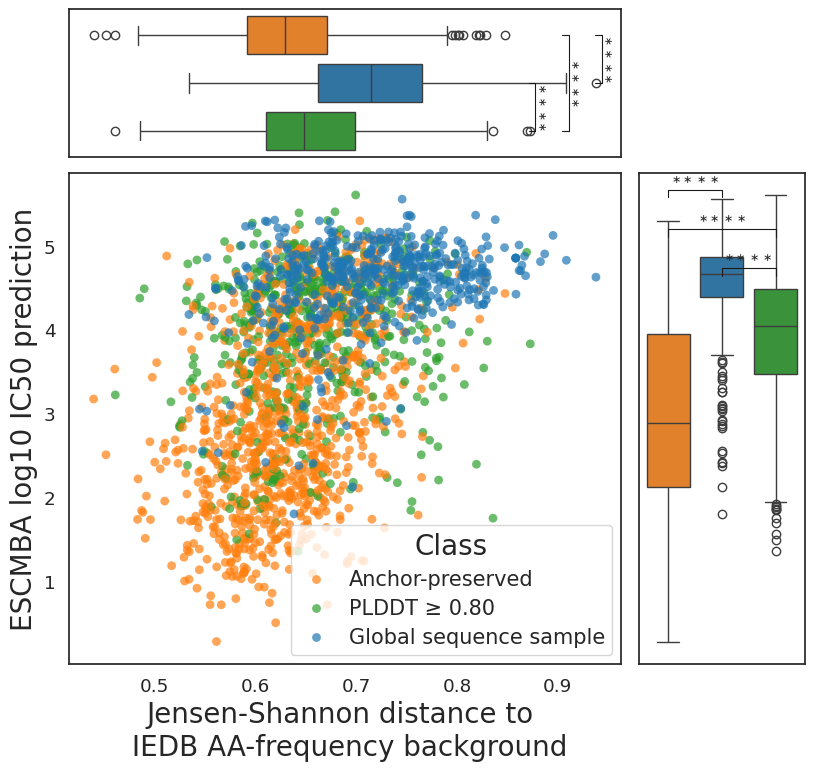

Saved figure to: ../figures/scatter_with_marginal_boxplots_mwu.pdf


In [14]:
from matplotlib import gridspec
from scipy.stats import mannwhitneyu

# --- Prep / filtering ---
plddt_thr = 0.80
palette = {
    "Anchor-preserved":        "tab:orange",
    "Global sequence sample":  "tab:blue",
    f"PLDDT ≥ {plddt_thr:.2f}": "tab:green",
}
keep_methods = ["Anchor-preserved", "Global sequence sample", f"PLDDT ≥ {plddt_thr:.2f}"]
dt_clean = (
    dt[dt["Method"].isin(keep_methods)]
      .dropna(subset=["JS_dist", "prediction_x", "Method"])
      .copy()
)
method_order = [m for m in keep_methods if m in dt_clean["Method"].unique()]

# --- helpers ---
def _p_to_stars(p):
    return "ns" if p >= 0.05 else ("*" if p >= 0.01 else ("**" if p >= 0.001 else ("***" if p >= 1e-4 else "****")))

def pairwise_mwu(df, group_col, value_col, order):
    pvals = {}
    for i in range(len(order)):
        for j in range(i+1, len(order)):
            g1 = df.loc[df[group_col] == order[i], value_col].dropna().values
            g2 = df.loc[df[group_col] == order[j], value_col].dropna().values
            if len(g1) and len(g2):
                pvals[(i, j)] = mannwhitneyu(g1, g2, alternative="two-sided").pvalue
    return pvals

def add_sig_bars_horizontal_inaxes(ax, order, pvals, x_pos=0.98, dx=0.04):
    """For horizontal boxplot (JS_dist on x). Bars drawn in axes coords so limits do not change."""
    y_ticks = np.arange(len(order))
    k = 0
    for (i, j), p in pvals.items():
        # vertical bar near the right edge, inside [0,1] axes coords
        x = x_pos - k*dx
        ax.annotate("", xy=(x, j), xytext=(x, i),
                    xycoords=("axes fraction", "data"), textcoords=("axes fraction", "data"),
                    arrowprops=dict(arrowstyle="-", color="k", lw=1))
        # caps
        ax.plot([x-0.01, x], [i, i], transform=ax.get_xaxis_transform(which='grid'), color="k", lw=1)
        ax.plot([x-0.01, x], [j, j], transform=ax.get_xaxis_transform(which='grid'), color="k", lw=1)
        # stars
        ax.text(x+0.005, (i+j)/2, _p_to_stars(p),
                transform=ax.get_yaxis_transform(which='grid'),
                va="center", ha="left", rotation=90, fontsize=13)
        k += 1

def add_sig_bars_vertical_inaxes(ax, order, pvals, y_pos=0.98, dy=0.08):
    """For vertical boxplot (prediction_x on y). Bars drawn in axes coords so limits do not change."""
    x_ticks = np.arange(len(order))
    k = 0
    for (i, j), p in pvals.items():
        y = y_pos - k*dy
        ax.annotate("", xy=(j, y), xytext=(i, y),
                    xycoords=("data", "axes fraction"), textcoords=("data", "axes fraction"),
                    arrowprops=dict(arrowstyle="-", color="k", lw=1))
        # caps
        ax.plot([i, i], [y-0.015, y], transform=ax.get_yaxis_transform(which='grid'), color="k", lw=1)
        ax.plot([j, j], [y-0.015, y], transform=ax.get_yaxis_transform(which='grid'), color="k", lw=1)
        # stars
        ax.text((i+j)/2, y+0.01, _p_to_stars(p),
                transform=ax.get_yaxis_transform(which='grid'),
                ha="center", va="bottom", fontsize=13)
        k += 1

# --- figure layout (share axes) ---
sns.set(style="white", font_scale=1.2)
fig = plt.figure(figsize=(9.5, 8.5))
gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1.2], height_ratios=[1.2, 4],
                       wspace=0.05, hspace=0.05)

# Main scatter first
ax_main = fig.add_subplot(gs[1, 0])
sns.scatterplot(
    data=dt_clean, x="JS_dist", y="prediction_x",
    hue="Method", palette=palette, alpha=0.7, s=40, edgecolor="none", ax=ax_main
)
ax_main.grid(False)
leg = ax_main.legend(title="Class", frameon=True, loc="lower right", fontsize=13)
ax_main.set_xlabel("Jensen-Shannon distance to \n IEDB AA-frequency background", fontsize=20)
ax_main.set_ylabel("ESCMBA log10 IC50 prediction", fontsize=20)

# Top boxplot shares X with main
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
sns.boxplot(
    data=dt_clean, x="JS_dist", y="Method",
    order=method_order, palette=palette, orient="h", ax=ax_top
)
ax_top.set_xlabel("")
ax_top.set_ylabel("")
# Hide tick labels but keep ticks aligned with main
ax_top.tick_params(left=False, labelleft=False)
ax_top.grid(False)

# Right boxplot shares Y with main
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)
sns.boxplot(
    data=dt_clean, x="Method", y="prediction_x",
    order=method_order, palette=palette, orient="v", ax=ax_right
)
ax_right.set_xlabel("")
ax_right.set_ylabel("")
ax_right.tick_params(bottom=False, labelbottom=False)
ax_right.grid(False)

# Force identical ticks to follow the main axes
ax_top.set_xticks(ax_main.get_xticks())
ax_right.set_yticks(ax_main.get_yticks())

# Top boxplot
ax_top.tick_params(
    left=False, labelleft=False, bottom=False, labelbottom=False,  # no labels
    length=0  # <--- removes the tick marks themselves
)

# Right boxplot
ax_right.tick_params(
    left=False, labelleft=False, bottom=False, labelbottom=False,  # no labels
    length=0  # <--- removes the tick marks themselves
)


from matplotlib.transforms import blended_transform_factory

def _p_to_stars_math(p):
    """Return significance stars in mathtext (small, clean)."""
    if p >= 0.05:   return r"$\mathrm{ns}$"
    if p >= 0.01:   return r"$\ast$"
    if p >= 0.001:  return r"$\ast\ast$"
    if p >= 1e-4:   return r"$\ast\ast\ast$"
    return r"$\ast\ast\ast\ast$"

def add_sig_bars_horizontal(ax, order, pvals, x_pos=0.965, dx=0.06, cap_frac=0.012, text_rot=90):
    """Thin vertical connectors for horizontal boxplots (JS_dist)."""
    trans = blended_transform_factory(ax.transAxes, ax.transData)
    k = 0
    for (i, j), p in sorted(pvals.items()):
        x = x_pos - k*dx
        # connector
        ax.plot([x, x], [i, j], transform=trans, color="k", lw=0.8, clip_on=False, zorder=6)
        # caps
        ax.plot([x - cap_frac, x], [i, i], transform=trans, color="k", lw=0.8, clip_on=False, zorder=6)
        ax.plot([x - cap_frac, x], [j, j], transform=trans, color="k", lw=0.8, clip_on=False, zorder=6)
        # stars
        ax.text(x + 0.004, (i + j) / 2.0, _p_to_stars_math(p),
                transform=trans, va="center", ha="left",
                rotation=text_rot, fontsize=8, clip_on=False)#,
                # bbox=dict(boxstyle="round,pad=0.12",  ec="none", alpha=0.8), zorder=7)
        k += 1

def add_sig_bars_vertical(ax, order, pvals, y_pos=0.965, dy=0.08, cap_frac=0.015):
    """Thin horizontal connectors for vertical boxplots (prediction_x)."""
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    k = 0
    for (i, j), p in sorted(pvals.items()):
        y = y_pos - k*dy
        # connector
        ax.plot([i, j], [y, y], transform=trans, color="k", lw=0.8, clip_on=False, zorder=6)
        # caps
        ax.plot([i, i], [y - cap_frac, y], transform=trans, color="k", lw=0.8, clip_on=False, zorder=6)
        ax.plot([j, j], [y - cap_frac, y], transform=trans, color="k", lw=0.8, clip_on=False, zorder=6)
        # stars
        ax.text((i + j) / 2.0, y + 0.012, _p_to_stars_math(p),
                transform=trans, va="bottom", ha="center",
                fontsize=8, clip_on=False)#,
                # bbox=dict(boxstyle="round,pad=0.12", ec="none", alpha=0.8), zorder=7)
        k += 1

# --- Compute and draw significance ---
pvals_top   = pairwise_mwu(dt_clean, "Method", "JS_dist",  method_order)
pvals_right = pairwise_mwu(dt_clean, "Method", "prediction_x", method_order)
add_sig_bars_horizontal(ax_top,   method_order, pvals_top)
add_sig_bars_vertical(  ax_right, method_order, pvals_right)


# Legend sizing
plt.setp(leg.get_title(), fontsize=20)
for t in leg.get_texts():
    t.set_fontsize(15)

plt.tight_layout()
os.makedirs("../figures", exist_ok=True)
out_path = "../figures/scatter_with_marginal_boxplots_mwu.pdf"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {out_path}")


In [19]:
from statsmodels.stats.multitest import multipletests

# Convert dict values to array for correction
pvals_dist_arr = np.array(list(pvals_dist.values()))
pvals_aff_arr  = np.array(list(pvals_aff.values()))

# Benjamini–Hochberg correction (FDR)
_, pvals_dist_adj, _, _ = multipletests(pvals_dist_arr, method='fdr_bh')
_, pvals_aff_adj, _, _  = multipletests(pvals_aff_arr, method='fdr_bh')

# Map back to pair labels
pairs_dist_adj = dict(zip(pvals_dist.keys(), pvals_dist_adj))
pairs_aff_adj  = dict(zip(pvals_aff.keys(), pvals_aff_adj))

print("JS distance adjusted p-values:")
for (i, j), p in pairs_dist_adj.items():
    print(f"{method_order[i]} vs {method_order[j]} : adj p = {p:.3e}")

print("\nIC50 adjusted p-values:")
for (i, j), p in pairs_aff_adj.items():
    print(f"{method_order[i]} vs {method_order[j]} : adj p = {p:.3e}")


JS distance adjusted p-values:
Anchor-preserved vs Global sequence sample : adj p = 4.818e-80
Anchor-preserved vs PLDDT ≥ 0.80 : adj p = 6.034e-11
Global sequence sample vs PLDDT ≥ 0.80 : adj p = 2.976e-34

IC50 adjusted p-values:
Anchor-preserved vs Global sequence sample : adj p = 1.240e-123
Anchor-preserved vs PLDDT ≥ 0.80 : adj p = 2.378e-40
Global sequence sample vs PLDDT ≥ 0.80 : adj p = 4.269e-59


In [29]:
rfd_peptides_all['pdb_id'].nunique()

119